### Compare models in terms of behavior, model fit, etc. 

In [1]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import pandas as pd
import utils.behavioral_utils as behavioral_utils
import utils.information_utils as information_utils
import utils.visualization_utils as visualization_utils
import utils.glm_utils as glm_utils
from matplotlib import pyplot as plt
import utils.spike_utils as spike_utils
from constants.glm_constants import *
from constants.behavioral_constants import *

import seaborn as sns
plt.rcParams.update({'font.size': 16})

In [11]:
MODEL_NAME_TO_DISPLAY = {
    "monkey": "Monkey",
    "BeliefStateAgent": "Belief state",
    "NivFeatRLwDecayAgent": "Feature RL w. decay",
    "BayesOptimalBeliefStateAgent": "Bayes optimal",
    "StimulusResponseAgent": "Stimulus/Response",
}

DISPLAY_NAME_TO_COLOR = {
    "Monkey": "black",
    "Belief state": "tab:pink",
    "Feature RL w. decay": "tab:cyan",
    "Bayes optimal": "tab:purple",
    "Stimulus/Response": "tab:olive",
}



In [12]:
def load_model_data(session, model_name, sub):
    if model_name == "BeliefStateAgent" or model_name == "NivFeatRLwDecayAgent":
        beh_path = f"/data/patrick_res/behavior/models/model_beh/{model_name}_{sub}/{session}.csv"  
    else: 
        beh_path = f"/data/patrick_res/behavior/models/model_beh/{model_name}/{session}.csv"  
    beh = pd.read_csv(beh_path)
    feature_selections = behavioral_utils.get_selection_features(beh)
    beh = pd.merge(beh, feature_selections, on="TrialNumber", how="inner")
    beh["session"] = session
    return beh

def load_model_beh_for_sub(model_name, sub):
    res = []
    for i in range(50):
        res.append(load_model_data(i, model_name, sub))
    return pd.concat(res)

def compute_probs(beh):
    cur_res = beh.groupby(["session"], group_keys=True).apply(lambda group: behavioral_utils.get_prob_correct_by_block_pos(group, 40)).reset_index()
    cur_res["type"] = "Current Rule"
    cur_res["Prob Chose"] = cur_res["ProbCorrect"]

    prev_res = beh.groupby(["session"], group_keys=True).apply(lambda group: behavioral_utils.get_prob_perseveration_by_block_pos(group, 40)).reset_index()
    prev_res["type"] = "Previous Rule"
    prev_res["Prob Chose"] = prev_res["Prob Perseverate"]
    all_data = pd.concat([cur_res, prev_res])
    return all_data

def get_probs(sub):
    all_probs = []
    for beh_type in MODEL_NAME_TO_DISPLAY: 
        if beh_type == "monkey":
            beh = behavioral_utils.load_all_beh_for_sub(sub)
        else: 
            beh = load_model_beh_for_sub(beh_type, sub)

        sub_probs = compute_probs(beh)
        sub_probs["beh_type"] = MODEL_NAME_TO_DISPLAY[beh_type]
        all_probs.append(sub_probs)
    return pd.concat(all_probs)


def get_accuracy(sub):
    all_perf = []
    for beh_type in MODEL_NAME_TO_DISPLAY:
        if beh_type == "monkey":
            continue
        perf = pd.read_pickle(f"/data/patrick_res/behavior/models/model_train_test_perfs/{beh_type}_{sub}_perfs.pickle")
        perf["beh_type"] = MODEL_NAME_TO_DISPLAY[beh_type]
        all_perf.append(perf)
    return pd.concat(all_perf)


def load_vars(row, sub, model_name):
    data = pd.read_pickle(f"/data/patrick_res/behavior/models/inferred_variables/{model_name}_{sub}/{row.session_name}.pickle")
    data["session"] = row.session_name
    return data


def get_belief_value_pairs(sub):
    valid_sessions = pd.read_pickle(SESSIONS_PATH.format(sub=sub))
    beliefs = pd.concat(valid_sessions.apply(lambda x: load_vars(x, sub, "BeliefStateAgent"), axis=1).values)
    feat_values = pd.concat(valid_sessions.apply(lambda x: load_vars(x, sub, "NivFeatRLwDecayAgent"), axis=1).values)
    merged = pd.merge(beliefs, feat_values, on=["TrialNumber", "session"])

    all_beliefs = []
    all_values = []
    for feat in FEATURES:
        all_beliefs.append(merged[f"{feat}Prob"].values)
        all_values.append(merged[f"{feat}Value"].values)
    return np.concatenate(all_beliefs), np.concatenate(all_values)

def plot_all(acccuries, probs, belief_value_pairs): 
    rng = np.random.default_rng()
    fig, axs = plt.subplots(2, 2, figsize=(9, 10))
    ax = axs[0, 0]
    sns.barplot(acccuries, x="beh_type", y="test_acc", palette=DISPLAY_NAME_TO_COLOR, ax=ax)
    ax.axhline(0.25, color='black', linestyle='dotted', label="Chance")
    ax.set_xlabel("")
    ax.set_ylabel("Prediction Accuracy")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')
    visualization_utils.format_plot(axs)
    fig.tight_layout()

    ax = axs[0, 1]
    beliefs, values = belief_value_pairs
    sample_idxs = rng.choice(len(beliefs), 10000)
    _, _, r_value, _, _ = visualization_utils.plot_and_calc_correlation(values[sample_idxs], beliefs[sample_idxs], ax)
    ax.set_xlabel("Feature value (Feature RL w. Decay)")
    ax.set_ylabel("Feature belief (Belief state)")
    ax.legend()

    ax = axs[1, 0]
    sns.lineplot(probs[probs["type"] == "Current Rule"], x="TrialInBlock", y="Prob Chose", hue="beh_type", palette=DISPLAY_NAME_TO_COLOR, errorbar="se", linewidth=3, ax=ax)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles[:5], labels=labels[:5])
    for line in ax.get_legend().get_lines():
        line.set_linewidth(4)
    ax.axhline(0.25, color='black', linestyle='dotted', label="Chance")
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Trials after rule switch")
    ax.set_ylabel("Prob. of selecting current rule") 

    ax = axs[1, 1]
    sns.lineplot(
        probs[(probs["type"] == "Previous Rule") & (probs["beh_type"] != "Stimulus optimal")], 
        x="TrialInBlock", y="Prob Chose", 
        hue="beh_type", palette=DISPLAY_NAME_TO_COLOR, errorbar="se", linewidth=3, ax=ax
    )
    ax.set_ylim(0, 1.05)
    ax.axhline(0.25, color='black', linestyle='dotted', label="Chance")
    ax.set_xlabel("Trials after rule switch")
    ax.set_ylabel("Prob. of selecting previous rule") 
    ax.get_legend().remove()
    return fig, axs



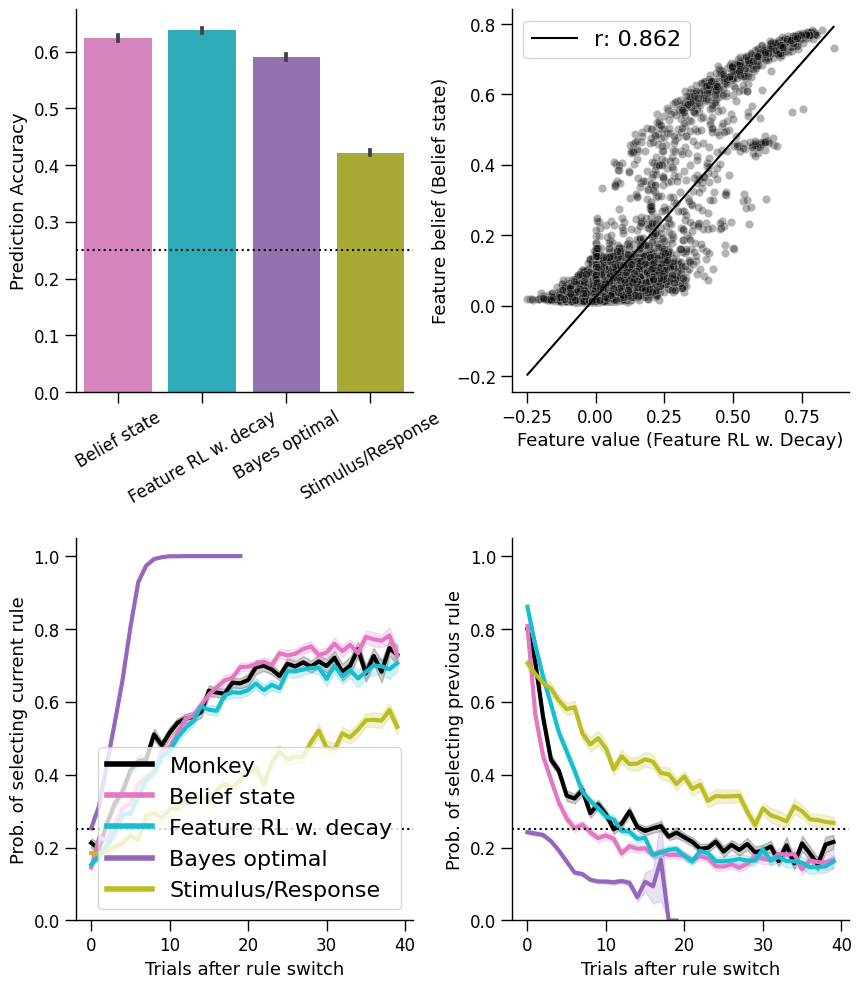

In [14]:
sub = "SA"

acccuries = get_accuracy(sub)
probs = get_probs(sub)
belief_value_pairs = get_belief_value_pairs(sub)
fig, axs = plot_all(acccuries, probs, belief_value_pairs)
fig.savefig("/data/patrick_res/figures/wcst_paper/behavior/SA_beh_models_extended.png")
fig.savefig("/data/patrick_res/figures/wcst_paper/behavior/SA_beh_models_extended.svg")

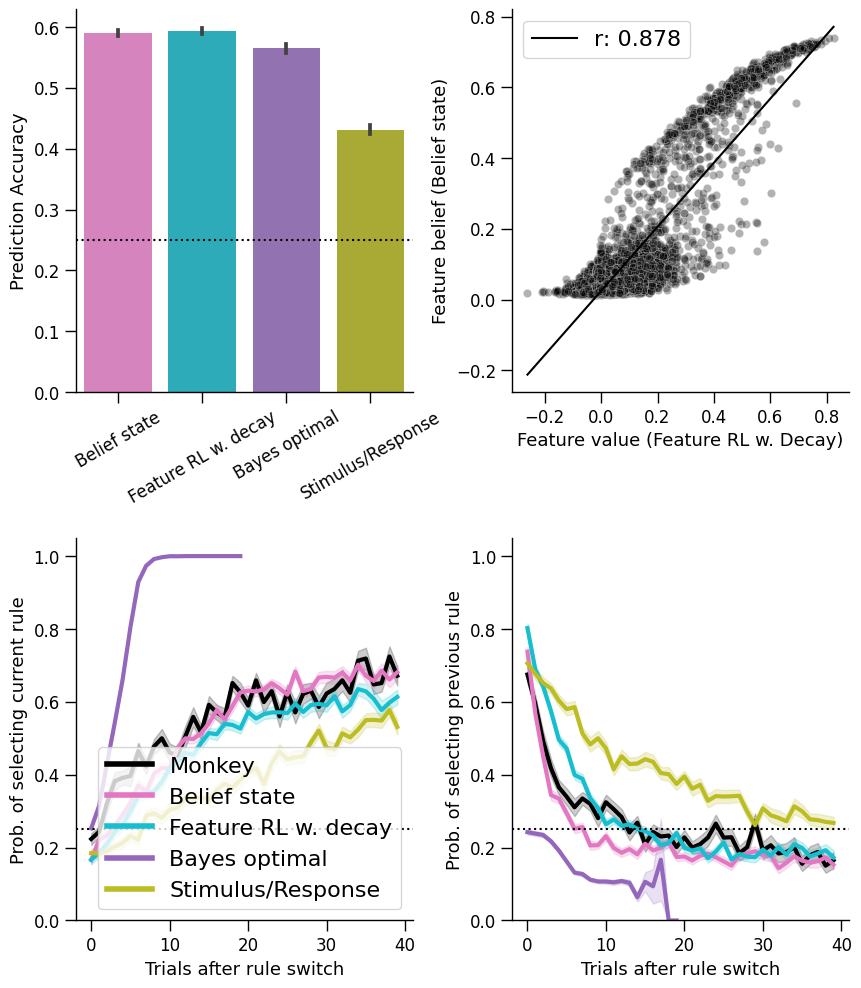

In [15]:
sub = "BL"

acccuries = get_accuracy(sub)
probs = get_probs(sub)
belief_value_pairs = get_belief_value_pairs(sub)
fig, ax = plot_all(acccuries, probs, belief_value_pairs)
fig.savefig("/data/patrick_res/figures/wcst_paper/behavior/BL_beh_models_extended.png")
fig.savefig("/data/patrick_res/figures/wcst_paper/behavior/BL_beh_models_extended.svg")

### Print SA examples in different sizes for main figure

In [16]:
sub = "SA"

acccuries = get_accuracy(sub)
probs = get_probs(sub)

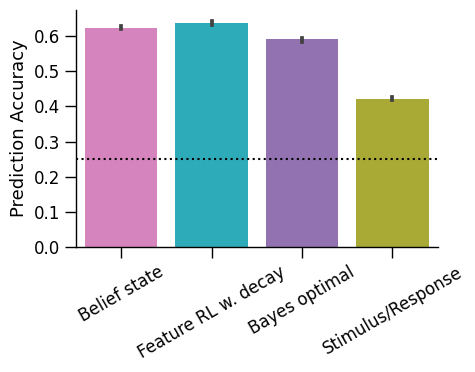

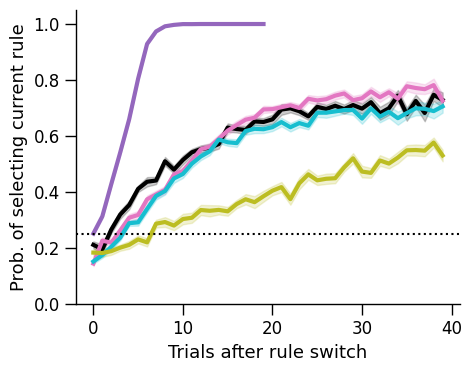

In [17]:

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(acccuries, x="beh_type", y="test_acc", palette=DISPLAY_NAME_TO_COLOR, ax=ax)
ax.axhline(0.25, color='black', linestyle='dotted', label="Chance")
ax.set_xlabel("")
ax.set_ylabel("Prediction Accuracy")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')
visualization_utils.format_plot(ax)
fig.tight_layout()
fig.savefig("/data/patrick_res/figures/wcst_paper/behavior/SA_model_prediction_acc_squished.png")
fig.savefig("/data/patrick_res/figures/wcst_paper/behavior/SA_model_prediction_acc_squished.svg")

fig, ax = plt.subplots(figsize=(5, 4))
sns.lineplot(probs[probs["type"] == "Current Rule"], x="TrialInBlock", y="Prob Chose", hue="beh_type", palette=DISPLAY_NAME_TO_COLOR, errorbar="se", linewidth=3, ax=ax)
handles, labels = ax.get_legend_handles_labels()
# ax.legend(handles=handles[:5], labels=labels[:5])
# for line in ax.get_legend().get_lines():
#     line.set_linewidth(4)
ax.get_legend().remove()
ax.axhline(0.25, color='black', linestyle='dotted', label="Chance")
ax.set_ylim(0, 1.05)
ax.set_xlabel("Trials after rule switch")
ax.set_ylabel("Prob. of selecting current rule") 
visualization_utils.format_plot(ax)
fig.tight_layout()
fig.savefig("/data/patrick_res/figures/wcst_paper/behavior/SA_model_prob_current_rule_squished.png")
fig.savefig("/data/patrick_res/figures/wcst_paper/behavior/SA_model_prob_current_rule_squished.svg")
